In [97]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML

rd.random.seed(67123)

In [98]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [99]:
collector = rd.MetricCollector()

best_score = rd.metric("scores").min()

sma_5 = best_score.rolling(5).mean()
sma_10 = best_score.rolling(10).mean()
sma_20 = best_score.rolling(20).mean()

sma_10_stddev = best_score.rolling(10).stddev()

# plateau = rd.metric("scores").min().rolling(10).stddev() <= 0.001

# mutation_rate = rd.when(plateau).then(0.12).otherwise(0.06)
# crossover_rate = rd.when(plateau).then(0.03).otherwise(0.06)


diversity = rd.metric("rate.diversity").rolling(10).mean()
progress = ((sma_5 - sma_20) / (sma_20 + 1e-6)).clamp(0.0, 1.0)
score_stddev = rd.metric("scores").min().rolling(10).stddev()
slope = rd.metric("scores.best").rolling(10).slope()
slope_div = rd.metric("rate.diversity").rolling(10).slope()

pressure = (
    (
        rd.lit(0.5)
        * (
            (rd.lit(0.02) - progress)
            + rd.lit(0.8) * (rd.lit(0.7) - diversity)
            + rd.lit(0.4) * (-slope_div)
        )
    )
    # .rolling(10)
    # .mean()
    .clamp(0.0, 1.0)
)

crossover_rate = (
    rd.lit(0.05)
    * (
        rd.lit(1.0)
        + rd.lit(0.5) * diversity
        + rd.lit(0.3) * progress
        - rd.lit(0.3) * (-slope_div).clamp(0.0, 0.5)
    )
).clamp(0.01, 0.12)

norm_slope = (slope / (score_stddev + rd.lit(1e-6))).clamp(-1.0, 1.0)

progress = ((sma_20 - sma_5) / (sma_20 + rd.lit(1e-6))).clamp(0.0, 1.0)
diversity = rd.metric("rate.diversity").rolling(10).mean().clamp(0.0, 1.0)
flatness = (rd.lit(0.001) - abs(slope)).clamp(0.0, 1.0)
div_collapse = (rd.lit(0.0) - slope_div).clamp(0.0, 1.0)
low_volatility = (rd.lit(0.05) - score_stddev).clamp(0.0, 1.0)

w0, w1, w2, w3, w4, w5 = 0.02, 0.5, 0.4, 0.4, 0.4, 0.4

pressure = (
    rd.lit(w0)
    + rd.lit(w1) * (rd.lit(0.2) - progress)
    + rd.lit(w2) * (rd.lit(0.7) - diversity)
    + rd.lit(w3) * div_collapse
    + rd.lit(w4) * flatness
    + rd.lit(w5) * (rd.lit(0.05) - low_volatility)
).clamp(0.0, 1.0)

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .metrics(
        slope=norm_slope,
        # div=diversity,
        # slope_div=slope_div,
        # score_stddev=score_stddev,
        pressure=pressure,
        # sma_5=explore_scaled_with_diversity,
        # sma_10=needs_to_expore_signal,
        # sma_20=diversity,
        # progress=progress,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-04-13T14:25:26.777848Z  INFO Epoch 1    | Score:   2.0038 | Time: 192.08µs
2026-04-13T14:25:26.777968Z  INFO Epoch 2    | Score:   2.0038 | Time: 269.12µs
2026-04-13T14:25:26.778069Z  INFO Epoch 3    | Score:   2.0038 | Time: 338.46µs
2026-04-13T14:25:26.778164Z  INFO Epoch 4    | Score:   2.0038 | Time: 400.62µs
2026-04-13T14:25:26.778273Z  INFO Epoch 5    | Score:   1.6821 | Time: 473.67µs
2026-04-13T14:25:26.778371Z  INFO Epoch 6    | Score:   1.6821 | Time: 540.42µs
2026-04-13T14:25:26.778475Z  INFO Epoch 7    | Score:   1.6821 | Time: 610.75µs
2026-04-13T14:25:26.778577Z  INFO Epoch 8    | Score:   1.6821 | Time: 676.62µs
2026-04-13T14:25:26.778692Z  INFO Epoch 9    | Score:   1.6821 | Time: 748.71µs
2026-04-13T14:25:26.778802Z  INFO Epoch 10   | Score:   1.6821 | Time: 821.83µs
2026-04-13T14:25:26.778926Z  INFO Epoch 11   | Score:   1.6821 | Time: 910.54µs
2026-04-13T14:25:26.779031Z  INFO Epoch 12   | Score:   1.6821 | Time: 980.04µs
2026-04-13T14:25:26.779129Z  INFO Epoch 

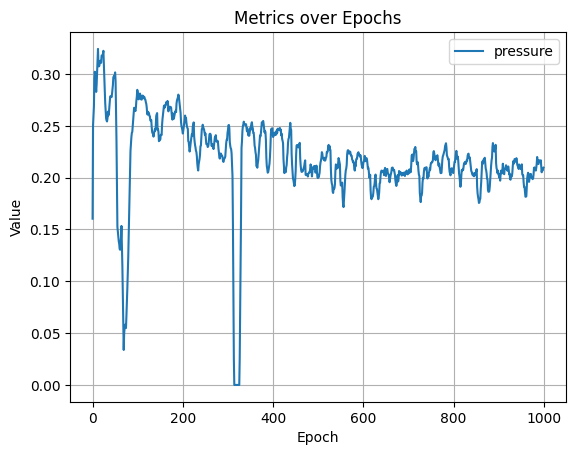

In [100]:
collector.plot(
    # "sma_5",
    # "sma_10",
    # "sma_20",
    # "progress",
    # "slope",
    # "div",
    # "score_stddev",
    # "slope",
    # "slope_div",
    "pressure",
    # "scores.best",
    # "crossover.graph.rate",
    # "mutate.operation.rate",
    # "crossover.graph.rate",
)

In [101]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)

print(result)
print(result.metrics().dashboard())
print(accuracy)


(
	index=1000,
	score=[0.089826],
	dtype=Struct({'GraphNode': Struct({'op': Float32})}),
	MetricSet[metrics=42, updates=198775],
	value=Graph(
[0  ] [147386 ] "Inp" :: Zero  Var: X0(0)   V:true  R:false 0  5  < []
[1  ] [147388 ] "Out" :: Any   Fn: linear   V:true  R:false 6  0  < [0, 2, 3, 4, 6, 10]
[2  ] [147390 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  2  < [0]
[3  ] [147089 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  2  < [0]
[4  ] [147744 ] "Ver" :: 2     Fn: mul      V:true  R:false 2  2  < [3, 7]
[5  ] [148066 ] "Edg" :: 1     Val: w(-1.3997302) V:true  R:false 1  1  < [11]
[6  ] [148259 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  1  < [4]
[7  ] [150413 ] "Ver" :: Any   Fn: linear   V:true  R:false 2  1  < [9, 12]
[8  ] [152591 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  2  < [0]
[9  ] [154077 ] "Ver" :: 2     Fn: mul      V:true  R:false 2  1  < [0, 2]
[10 ] [154113 ] "Edg" :: 1     Val: w(-0.81586945) V:true  R:false 1  1  < [8]
[11 ] [158772 ] "Ver" :: A

In [102]:
df = collector.to_polars(lazy=False)
df


name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""step.audit""",0.0,null,null,null,null,null,null,null,1,39µs,39µs,0µs,39µs,39µs,0µs,0,1,"[""time"", ""step""]"
"""index""",1.0,1.0,1.0,0.0,0.0,NaN,1.0,1.0,1,null,null,null,null,null,null,0,0,"[""statistic""]"
"""scores.best""",2.003778,2.003778,2.003778,0.0,0.0,NaN,2.003778,2.003778,1,null,null,null,null,null,null,0,1,"[""statistic"", ""score""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,9µs,9µs,0µs,9µs,9µs,0µs,0,2,"[""selector"", ""statistic"", ""time""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,5µs,5µs,0µs,5µs,5µs,0µs,0,2,"[""selector"", ""statistic"", ""time""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""crossover.graph""",0.0,127.0,0.127,0.518787,0.26914,0.0,0.0,7.0,1000,1870µs,1µs,7µs,0µs,230µs,0µs,999,2,"[""alterer"", ""crossover"", … ""time""]"
"""score.improvement""",1.0,41.0,1.0,0.0,0.0,0.0,1.0,1.0,41,null,null,null,null,null,null,632,1,"[""statistic"", ""score""]"
"""age""",0.0,533978.0,5.33978,5.577921,31.113201,0.965052,0.0,20.0,100000,null,null,null,null,null,null,999,100,"[""age"", ""statistic"", ""distribution""]"


In [103]:
filtered = (
    df.filter(pl.col("name") == "score.improvement")
    .select("version")
    .unique()
    .sort("version")
)
filtered

version
i64
0
4
51
54
57
…
474
554
575


In [104]:
display(HTML(filtered._repr_html_()))

version
i64
0
4
51
54
57
…
474
554
575
